In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from sunpy.visualization.colormaps import color_tables
from omegaconf import OmegaConf

from sdofmv2.core import SDOMLDataModule, MAE, inverse_log_norm
from sdofmv2.tasks.missing_data import MissingDataModel

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

In [3]:
cfg = OmegaConf.load("../../../../configs/downstream/missing_channel_sdofmv2_ALL.yaml")

cache_dir = "../../../../assets/cache/missing_channel/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.hmi,
        )
        if cfg.data.sdoml.sub_directory.hmi
        else None
    ),
    aia_path=(
        os.path.join(
            cfg.data.sdoml.base_directory,
            cfg.data.sdoml.sub_directory.aia,
        )
        if cfg.data.sdoml.sub_directory.aia
        else None
    ),
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    pin_memory=cfg.data.pin_memory,
    persistent_workers=cfg.data.persistent_workers,
    multiprocessing_context=cfg.data.multiprocessing_context,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    hmi_mask_path=cfg.data.hmi_mask,
    apply_mask=cfg.data.sdoml.apply_mask,
    num_frames=cfg.data.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    precision=cfg.experiment.precision,
)
data_module.setup()
channels = data_module.wavelengths

2026-06-16 02:24:11.056 | INFO     | sdofmv2.core.datamodule:setup:643 - Train dataloader is ready!
2026-06-16 02:24:11.057 | INFO     | sdofmv2.core.datamodule:setup:644 - Dataset size: 27049
2026-06-16 02:24:11.059 | INFO     | sdofmv2.core.datamodule:setup:662 - Validation dataloader is ready!
2026-06-16 02:24:11.060 | INFO     | sdofmv2.core.datamodule:setup:663 - Dataset size: 2749
2026-06-16 02:24:11.062 | INFO     | sdofmv2.core.datamodule:setup:681 - test dataloader is ready!
2026-06-16 02:24:11.063 | INFO     | sdofmv2.core.datamodule:setup:682 - Dataset size: 2888


In [9]:
backbone = MAE.load_from_checkpoint(
    os.path.join("../../../../assets/checkpoints/backbone/ALL/", cfg.experiment.backbone.weight_name),
    map_location="cpu",
    weights_only=False,
    masking_ratio=0.0
)

model = MissingDataModel.load_from_checkpoint(
    "../../../../assets/checkpoints/missing_channel/missing-channel-best-sdofmv2-all.ckpt",
    backbone=backbone,
    map_location="cpu",
    weights_only=False,
)

In [10]:
cms_dict = {
    "131A": sunpycm.cmlist.get("sdoaia131"),
    "1600A": sunpycm.cmlist.get("sdoaia1600"),
    "1700A": sunpycm.cmlist.get("sdoaia1700"),
    "171A": sunpycm.cmlist.get("sdoaia171"),
    "193A": sunpycm.cmlist.get("sdoaia193"),
    "211A": sunpycm.cmlist.get("sdoaia211"),
    "304A": sunpycm.cmlist.get("sdoaia304"),
    "335A": sunpycm.cmlist.get("sdoaia335"),
    "94A": sunpycm.cmlist.get("sdoaia94"),
    "Bx": color_tables.hmi_mag_color_table(),
    "By": color_tables.hmi_mag_color_table(),
    "Bz": color_tables.hmi_mag_color_table(),
}

In [11]:
# Input
timestamps = [
    "2019-12-01 00:12:00",
    "2019-12-10 00:12:00",
    "2019-12-20 00:12:00",
    "2019-12-30 00:12:00"
    ]
img_indices = [
    data_module.test_ds.aligndata.index.get_loc(pd.to_datetime(i_time)) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]
print(f"Datetime: {ts}")

Datetime: [Timestamp('2019-12-01 00:12:00'), Timestamp('2019-12-10 00:12:00'), Timestamp('2019-12-20 00:12:00'), Timestamp('2019-12-30 00:12:00')]


In [12]:
corrupted_img = x_set.clone()
# Use config for corrupted_channel_index, fallback to 5
corrupted_channel = cfg.experiment.get("corrupted_channel_index", 5)
corrupted_img[:, corrupted_channel, :, :, :] = 0

# output denorm
loss, x_hat, mask = model(corrupted_img)
x_hat_zero, _ = backbone(corrupted_img)

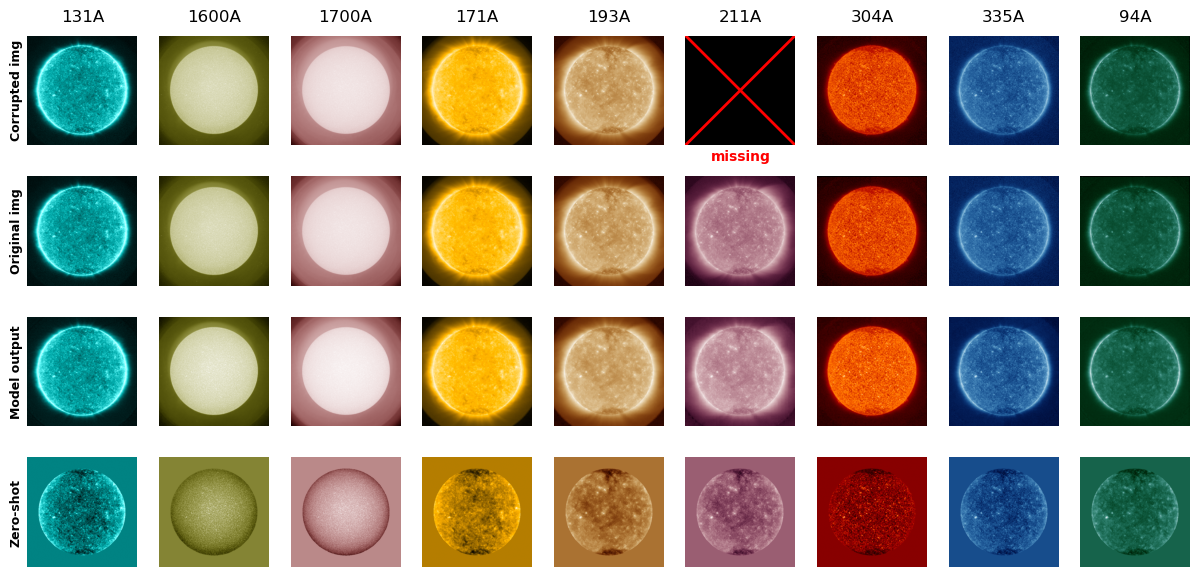

In [14]:
x_hat_np = x_hat.detach().numpy()
x_hat_zero_shot_np = x_hat_zero.detach().numpy()
limb_mask = backbone.limb_mask.detach().numpy()

fig, axes = plt.subplots(nrows=4, ncols=9, figsize=(15, 7))

# Turn off axes and spines for all subplots initially
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i_ch, ch in enumerate(channels):

    if ch == "211A":
        # Special handling for the 211 Å channel
        axes[0, i_ch].set_facecolor('black') # Set background to black
        axes[0, i_ch].set_aspect('equal')
        
        # Draw a red cross
        # We need to define the limits to draw the cross from corner to corner
        axes[0, i_ch].set_xlim(0, 1)
        axes[0, i_ch].set_ylim(0, 1)
        axes[0, i_ch].plot([0, 1], [0, 1], color='red', linewidth=2)
        axes[0, i_ch].plot([0, 1], [1, 0], color='red', linewidth=2)
        
        
        # Add the text
        axes[0, i_ch].text(0.5, -0.1, "missing", 
                color='red', 
                ha='center', 
                va='center', 
                fontsize=10, 
                fontweight='bold')

    axes[0, i_ch].imshow(corrupted_img[0, i_ch, 0, :, :], cmap=cms_dict[ch])
    axes[1, i_ch].imshow(x_set[0, i_ch, 0, :, :], cmap=cms_dict[ch])
    axes[2, i_ch].imshow(x_hat_np[0, i_ch, 0, :, :], cmap=cms_dict[ch])
    axes[3, i_ch].imshow(x_hat_zero_shot_np[0, i_ch, 0, :, :] * limb_mask, cmap=cms_dict[ch])

    
    # Set the title for all channels
    axes[0, i_ch].set_title(f"{ch}", fontsize=12, pad=10)


axes[0][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Corrupted img", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[0][0].transAxes # Ensures coordinates are relative to the subplot
    )

axes[1][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Original img", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[1][0].transAxes # Ensures coordinates are relative to the subplot
    )

axes[2][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Model output", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[2][0].transAxes # Ensures coordinates are relative to the subplot
    )

axes[3][0].text(
    -0.1, 0.5,              # Negative x moves it to the left
    f"Zero-shot", 
    ha='center', 
    va='center', 
    fontsize=9, 
    rotation=90,
    weight="bold",
    transform=axes[3][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.savefig("DS_missing_data_img_with_zeroshot.pdf", dpi=300, bbox_inches="tight")